<a href="https://colab.research.google.com/github/jhurley-blip/ECE4580/blob/main/module2_image_data_pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2: Image Data Pipelines
**Estimated time: 45 minutes**

In this module, we'll build a complete understanding of how PyTorch loads, transforms, and serves image data for training deep learning models. Efficient data pipelines are critical — even the best model will train poorly if it's starved of well-preprocessed data.

### Topics Covered
1. Loading datasets with `torchvision.datasets` (CIFAR-10, MNIST)
2. The `transforms` pipeline: resize, normalize, augment
3. `DataLoader`: batching, shuffling, `num_workers`
4. Visualizing a batch with `matplotlib`
5. **Exercise**: Build a custom `Dataset` class for a local image folder

---

## Setup & Imports

In [22]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from pathlib import Path
from PIL import Image
import os
import time

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f'PyTorch version  : {torch.__version__}')
print(f'Torchvision ver  : {torchvision.__version__}')
print(f'CUDA available   : {torch.cuda.is_available()}')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device     : {DEVICE}')

PyTorch version  : 2.10.0+cpu
Torchvision ver  : 0.25.0+cpu
CUDA available   : False
Using device     : cpu


---
## 1. Loading Datasets with `torchvision.datasets`

`torchvision.datasets` provides ready-made loaders for dozens of standard benchmarks. Under the hood, every dataset class inherits from `torch.utils.data.Dataset`, meaning it implements two required methods:

| Method | Purpose |
|--------|---------|
| `__len__()` | Returns the total number of samples |
| `__getitem__(idx)` | Returns the `(image, label)` pair at index `idx` |

### Key constructor arguments (shared by most torchvision datasets)

| Argument | Type | Description |
|---|---|---|
| `root` | `str` | Directory where data is stored/downloaded |
| `train` | `bool` | `True` for training split, `False` for test |
| `transform` | callable | Applied to the Python Imaging Library (PIL) image before returning |
| `target_transform` | callable | Applied to the label |
| `download` | `bool` | Download if not found locally |

### 1.1 MNIST — Handwritten Digits

MNIST is the classic benchmark: 70,000 grayscale 28×28 images of handwritten digits (0–9).
- **Training set**: 60,000 images
- **Test set**: 10,000 images
- **Classes**: 10 (digits 0–9)

# Transforms in PyTorch

Transforms in PyTorch are functions used to modify and preprocess image data, allowing for operations like resizing, cropping, and normalization. They can be combined into a pipeline to prepare data for training or inference in machine learning models.

---

## Overview

Transforms in PyTorch are essential tools used for preprocessing and augmenting image data. They are part of the `torchvision.transforms` module and help prepare data for training machine learning models.

---

## Types of Transforms

### Common Transformations

- **ToTensor** — Converts a PIL Image or NumPy array to a PyTorch tensor, scaling pixel values from `[0, 255]` to `[0.0, 1.0]`.
- **Normalize** — Adjusts the mean and standard deviation of the tensor image, which helps in standardizing the input data.
- **CenterCrop** — Crops the image at its center to a specified size.
- **RandomHorizontalFlip** — Randomly flips the image horizontally with a specified probability.

### Advanced Transformations

- **ColorJitter** — Randomly changes the brightness, contrast, saturation, and hue of the image.
- **RandomResizedCrop** — Crops the image to a specified size and resizes it, adding randomness to the cropping process.
- **FiveCrop** — Crops the image into four corners and the center crop, returning multiple images.

---

## Using Transforms

Transforms can be chained together using `Compose`, allowing for the creation of complex preprocessing pipelines. They can accept both PIL images and tensor images, making them versatile for various tasks in computer vision.

---

## Conclusion

Transforms are crucial for data augmentation and preprocessing in PyTorch, enhancing the model's ability to generalize by providing varied input data during training.


In [23]:
# A minimal transform: convert PIL Image → torch.Tensor
# We'll build richer pipelines in Section 2
basic_transform = transforms.ToTensor()

mnist_train = datasets.MNIST(
    root='./data',
    train=True,
    transform=basic_transform,
    download=True
)

mnist_test = datasets.MNIST(
    root='./data',
    train=False,
    transform=basic_transform,
    download=True
)

print(f'MNIST Training samples : {len(mnist_train):,}')
print(f'MNIST Test samples     : {len(mnist_test):,}')

# Inspect a single sample
image, label = mnist_train[0]
print(f'\nSample 0:')
print(f'  Image tensor shape : {image.shape}  (C x H x W)')
print(f'  Image dtype        : {image.dtype}')
print(f'  Pixel value range  : [{image.min():.3f}, {image.max():.3f}]')
print(f'  Label              : {label} → "{mnist_train.classes[label]}"')
print(f'\nClass names: {mnist_train.classes}')

MNIST Training samples : 60,000
MNIST Test samples     : 10,000

Sample 0:
  Image tensor shape : torch.Size([1, 28, 28])  (C x H x W)
  Image dtype        : torch.float32
  Pixel value range  : [0.000, 1.000]
  Label              : 5 → "5 - five"

Class names: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


### 1.2 CIFAR-10 — Color Images

CIFAR-10 contains 60,000 color 32×32 images across 10 object classes.
- **Training set**: 50,000 images
- **Test set**: 10,000 images  
- **Classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
- **Key difference from MNIST**: 3 color channels (RGB) instead of 1 (grayscale)

In [3]:
cifar10_train = datasets.CIFAR10(
    root='./data',
    train=True,
    transform=basic_transform,
    download=True
)

cifar10_test = datasets.CIFAR10(
    root='./data',
    train=False,
    transform=basic_transform,
    download=True
)

print(f'CIFAR-10 Training samples : {len(cifar10_train):,}')
print(f'CIFAR-10 Test samples     : {len(cifar10_test):,}')
print(f'Class names: {cifar10_train.classes}')

image, label = cifar10_train[0]
print(f'\nSample 0:')
print(f'  Image tensor shape : {image.shape}  (C x H x W)')
print(f'  Image dtype        : {image.dtype}')
print(f'  Pixel value range  : [{image.min():.3f}, {image.max():.3f}]')
print(f'  Label              : {label} → "{cifar10_train.classes[label]}"')

100%|██████████| 170M/170M [04:08<00:00, 686kB/s]


CIFAR-10 Training samples : 50,000
CIFAR-10 Test samples     : 10,000
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Sample 0:
  Image tensor shape : torch.Size([3, 32, 32])  (C x H x W)
  Image dtype        : torch.float32
  Pixel value range  : [0.000, 1.000]
  Label              : 6 → "frog"


### 1.3 Understanding the Dataset Contract

Every `Dataset` object (built-in or custom) behaves like a Python sequence — you can index it and ask for its length. This design lets `DataLoader` (Section 3) iterate over it without knowing anything about the underlying storage format.

In [4]:
# The Dataset contract in action
print('=== Dataset Contract ===')
print(f'len(cifar10_train)       = {len(cifar10_train)}')
print(f'type(cifar10_train[0])   = {type(cifar10_train[0])}')
print(f'type(cifar10_train[0][0])= {type(cifar10_train[0][0])} (the image tensor)')
print(f'type(cifar10_train[0][1])= {type(cifar10_train[0][1])} (the label)')

# You can slice/index freely
imgs = [cifar10_train[i][0] for i in range(5)]
print(f'\nFirst 5 labels: {[cifar10_train[i][1] for i in range(5)]}')
print(f'First 5 class names: {[cifar10_train.classes[cifar10_train[i][1]] for i in range(5)]}')

=== Dataset Contract ===
len(cifar10_train)       = 50000
type(cifar10_train[0])   = <class 'tuple'>
type(cifar10_train[0][0])= <class 'torch.Tensor'> (the image tensor)
type(cifar10_train[0][1])= <class 'int'> (the label)

First 5 labels: [6, 9, 9, 4, 1]
First 5 class names: ['frog', 'truck', 'truck', 'deer', 'automobile']


---
## 2. The `transforms` Pipeline

Raw images from disk are PIL Images with pixel values in `[0, 255]`. Neural networks expect **floating-point tensors** with values in a known, normalized range. The `transforms` module provides composable, callable objects that handle this conversion — and much more.

### How `transforms.Compose` works

```python
transform = transforms.Compose([
    transform_1,   # Applied first
    transform_2,   # Applied second
    transform_3,   # Applied third ...
])

# Equivalent to:
output = transform_3(transform_2(transform_1(image)))
```

Each transform is a callable that takes an image (PIL or tensor, depending on its position in the chain) and returns a transformed version.

### 2.1 Essential Transforms

In [5]:
# Grab a raw PIL image (before any transform)
raw_dataset = datasets.CIFAR10(root='./data', train=True, transform=None, download=False)
pil_image, label = raw_dataset[3]  # A PIL Image object

print(f'Raw PIL image type : {type(pil_image)}')
print(f'Raw PIL image mode : {pil_image.mode}')  # RGB
print(f'Raw PIL image size : {pil_image.size}')  # (W, H) note: PIL uses W,H order

# ─── Define each transform individually so we can study them ─────────────────

# 1. ToTensor — PIL Image (H,W,C) uint8 [0,255] → Tensor (C,H,W) float32 [0,1]
to_tensor = transforms.ToTensor()
tensor_img = to_tensor(pil_image)
print(f'\nAfter ToTensor:  shape={tensor_img.shape}, dtype={tensor_img.dtype}, range=[{tensor_img.min():.2f},{tensor_img.max():.2f}]')

# 2. Resize — change spatial resolution
resize = transforms.Resize((64, 64))   # upscale 32→64
resized = to_tensor(resize(pil_image))
print(f'After Resize(64): shape={resized.shape}')

# 3. CenterCrop / RandomCrop
crop = transforms.CenterCrop(24)       # crop 24x24 from center
cropped = to_tensor(crop(pil_image))
print(f'After CenterCrop(24): shape={cropped.shape}')

# 4. Normalize — (tensor - mean) / std, per channel
#    CIFAR-10 channel means and stds (pre-computed over training set)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)
normalize = transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
normalized = normalize(tensor_img)
print(f'After Normalize: range=[{normalized.min():.2f},{normalized.max():.2f}]  (roughly zero-centered)')

Raw PIL image type : <class 'PIL.Image.Image'>
Raw PIL image mode : RGB
Raw PIL image size : (32, 32)

After ToTensor:  shape=torch.Size([3, 32, 32]), dtype=torch.float32, range=[0.02,0.92]
After Resize(64): shape=torch.Size([3, 64, 64])
After CenterCrop(24): shape=torch.Size([3, 24, 24])
After Normalize: range=[-1.77,1.73]  (roughly zero-centered)


#### Why normalize?

Normalization shifts pixel values so that the distribution of activations entering the network has **zero mean and unit variance** (approximately). This:
- Speeds up gradient descent (loss landscape is more spherical)
- Prevents early layers from saturating sigmoid/tanh activations
- Ensures all three color channels contribute equally initially

The formula applied channel-wise is:  
$$x'_c = \frac{x_c - \mu_c}{\sigma_c}$$

The mean/std values should be computed from the **training set only**, then applied to validation/test sets — using test statistics would be data leakage.

### 2.2 Data Augmentation Transforms

Augmentation artificially expands the effective training set by applying **random, label-preserving** perturbations. Because they're random, every epoch each image looks slightly different to the model, which improves generalization.

> **Important**: Apply augmentation **only to the training set**. The validation/test pipeline should use only deterministic transforms (resize, normalize).

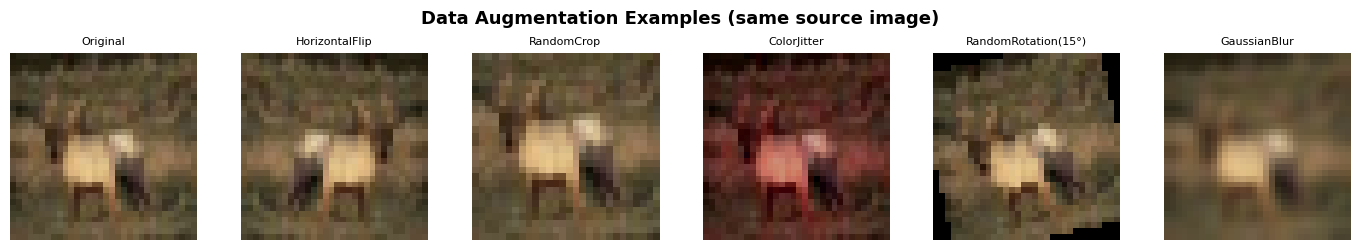

In [6]:
# ─── Common augmentation transforms ──────────────────────────────────────────
augment_transforms = {
    'Original'           : transforms.ToTensor(),
    'HorizontalFlip'     : transforms.Compose([transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor()]),
    'RandomCrop'         : transforms.Compose([transforms.RandomCrop(28, padding=4), transforms.ToTensor()]),
    'ColorJitter'        : transforms.Compose([transforms.ColorJitter(brightness=0.4, contrast=0.4,
                                                                       saturation=0.2, hue=0.1), transforms.ToTensor()]),
    'RandomRotation(15°)': transforms.Compose([transforms.RandomRotation(15), transforms.ToTensor()]),
    'GaussianBlur'       : transforms.Compose([transforms.GaussianBlur(kernel_size=3), transforms.ToTensor()]),
}

fig, axes = plt.subplots(1, len(augment_transforms), figsize=(14, 2.5))
fig.suptitle('Data Augmentation Examples (same source image)', fontsize=13, fontweight='bold')

for ax, (name, tfm) in zip(axes, augment_transforms.items()):
    t = tfm(pil_image)          # apply to PIL image, get tensor (C,H,W)
    img_np = t.permute(1,2,0).numpy().clip(0,1)
    ax.imshow(img_np)
    ax.set_title(name, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 2.3 Production-Ready Transform Pipelines

Now let's assemble complete, realistic pipelines for training and evaluation:

In [7]:
# ─── CIFAR-10 pipelines ───────────────────────────────────────────────────────

train_transform = transforms.Compose([
    # --- Augmentation (training only) ---
    transforms.RandomCrop(32, padding=4),          # pad 4px on each side, then crop back to 32
    transforms.RandomHorizontalFlip(p=0.5),        # 50% chance to mirror left↔right
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.2, hue=0.05
    ),
    # --- Required for all splits ---
    transforms.ToTensor(),                         # PIL [0,255] → Tensor [0,1]
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD) # channel-wise normalization
])

val_transform = transforms.Compose([
    # No augmentation — deterministic & repeatable
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

# Apply them to the datasets
cifar10_train_aug = datasets.CIFAR10(root='./data', train=True,  transform=train_transform, download=False)
cifar10_test_val  = datasets.CIFAR10(root='./data', train=False, transform=val_transform,   download=False)

# Confirm the pipeline produces properly normalized tensors
img_t, _ = cifar10_train_aug[0]
print('Train pipeline output:')
print(f'  shape : {img_t.shape}')
print(f'  dtype : {img_t.dtype}')
print(f'  mean  : {img_t.mean():.4f}  (should be near 0)')
print(f'  std   : {img_t.std():.4f}   (should be near 1)')

Train pipeline output:
  shape : torch.Size([3, 32, 32])
  dtype : torch.float32
  mean  : -0.7166  (should be near 0)
  std   : 0.9132   (should be near 1)


---
## 3. `DataLoader`: Batching, Shuffling, and Parallel Loading

A `Dataset` knows how to return *one sample*. A `DataLoader` wraps a `Dataset` and handles everything needed to serve *batches* to a training loop efficiently.

```
Dataset[0], Dataset[1], ..., Dataset[N-1]
         ↓  (DataLoader with batch_size=32)
Batch 0: samples [0..31]   → Tensor (32, C, H, W)
Batch 1: samples [32..63]  → Tensor (32, C, H, W)
...
```

### Key Arguments

| Argument | Default | Description |
|---|---|---|
| `dataset` | — | The `Dataset` to wrap |
| `batch_size` | 1 | Number of samples per batch |
| `shuffle` | `False` | Randomize order each epoch (set `True` for training) |
| `num_workers` | 0 | Subprocesses for data loading (0 = main process only) |
| `pin_memory` | `False` | Pre-allocate pinned memory for faster CPU→GPU transfer |
| `drop_last` | `False` | Drop the final incomplete batch |
| `collate_fn` | auto | Function to merge a list of samples into a batch |

### 3.1 Basic DataLoader Usage

In [8]:
BATCH_SIZE = 64

train_loader = DataLoader(
    dataset    = cifar10_train_aug,
    batch_size = BATCH_SIZE,
    shuffle    = True,         # Always shuffle training data
    num_workers= 2,            # 2 background processes load data while GPU trains
    pin_memory = True,         # Faster CPU → GPU data transfer
    drop_last  = False         # Keep the last (possibly smaller) batch
)

val_loader = DataLoader(
    dataset    = cifar10_test_val,
    batch_size = BATCH_SIZE * 2,  # No gradients → can use 2× batch size
    shuffle    = False,            # Never shuffle val/test — repeatable evaluation
    num_workers= 2,
    pin_memory = True
)

print(f'Training batches per epoch : {len(train_loader)}')
print(f'  ({len(cifar10_train_aug)} samples ÷ {BATCH_SIZE} batch_size = {len(cifar10_train_aug)/BATCH_SIZE:.1f})')
print(f'Validation batches         : {len(val_loader)}')

# Grab one batch and inspect its shape
images_batch, labels_batch = next(iter(train_loader))
print(f'\nOne training batch:')
print(f'  images_batch.shape : {images_batch.shape}   (B x C x H x W)')
print(f'  labels_batch.shape : {labels_batch.shape}   (B,)')
print(f'  images_batch.dtype : {images_batch.dtype}')
print(f'  labels_batch.dtype : {labels_batch.dtype}')

Training batches per epoch : 782
  (50000 samples ÷ 64 batch_size = 781.2)
Validation batches         : 79


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



One training batch:
  images_batch.shape : torch.Size([64, 3, 32, 32])   (B x C x H x W)
  labels_batch.shape : torch.Size([64])   (B,)
  images_batch.dtype : torch.float32
  labels_batch.dtype : torch.int64


### 3.2 Understanding `num_workers`

`num_workers` controls how many background CPU processes load and transform data *in parallel* with GPU training. The GPU would otherwise sit idle waiting for the CPU to prepare each batch.

```
num_workers=0 (no parallelism):
  [Load Batch 1] → [Train GPU] → [Load Batch 2] → [Train GPU] → ...
                   ↑ GPU idle        ↑ GPU idle

num_workers=4 (parallel loading):
  [Load B1][Load B2][Load B3][Load B4]  ← workers pre-load
            [Train B1][Train B2][Train B3]  ← GPU rarely waits
```

**Guidelines**:
- Start with `num_workers = 2` or `4`
- Increase until GPU utilization plateaus
- On macOS, use `num_workers=0` for notebooks (multiprocessing quirks)
- High `num_workers` can cause issues with small datasets (overhead > benefit)

In [9]:
# Benchmark: loading speed vs num_workers
def time_loader(num_workers, n_batches=20):
    loader = DataLoader(cifar10_train_aug, batch_size=64, shuffle=True,
                        num_workers=num_workers)
    t0 = time.time()
    for i, (x, y) in enumerate(loader):
        if i >= n_batches:
            break
    return time.time() - t0

print('Benchmarking num_workers (20 batches of 64)...')
for nw in [0, 1, 2, 4]:
    try:
        elapsed = time_loader(nw)
        print(f'  num_workers={nw}: {elapsed:.2f}s  ({20/elapsed:.1f} batches/sec)')
    except Exception as e:
        print(f'  num_workers={nw}: skipped ({e})')

Benchmarking num_workers (20 batches of 64)...
  num_workers=0: 1.16s  (17.3 batches/sec)
  num_workers=1: 1.32s  (15.2 batches/sec)
  num_workers=2: 1.09s  (18.3 batches/sec)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  num_workers=4: 1.72s  (11.7 batches/sec)


### 3.3 Shuffle and Reproducibility

Shuffling prevents the model from memorizing the *order* of training examples (which can introduce spurious correlations). However, for debugging you may want reproducible shuffling:

In [10]:
def make_reproducible_loader(dataset, seed=42):
    """DataLoader with reproducible shuffling via a seeded Generator."""
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=64,
        shuffle=True,
        generator=g,      # controls the shuffle permutation
        worker_init_fn=lambda worker_id: np.random.seed(seed + worker_id)
    )

loader_a = make_reproducible_loader(cifar10_train_aug, seed=42)
loader_b = make_reproducible_loader(cifar10_train_aug, seed=42)

labels_a = next(iter(loader_a))[1][:8].tolist()
labels_b = next(iter(loader_b))[1][:8].tolist()

print(f'Loader A first 8 labels: {labels_a}')
print(f'Loader B first 8 labels: {labels_b}')
print(f'Identical? {labels_a == labels_b}')

Loader A first 8 labels: [8, 8, 2, 7, 1, 7, 8, 9]
Loader B first 8 labels: [8, 8, 2, 7, 1, 7, 8, 9]
Identical? True


---
## 4. Visualizing a Batch with `matplotlib`

Visualization is a critical sanity-check step. Before training, always confirm that:
1. Images look correct (not corrupted, not upside-down, etc.)
2. Labels match what you see
3. Augmentations are reasonable (not too aggressive)

**Watch out**: `matplotlib` expects images in `(H, W, C)` format with values in `[0, 1]` (floats) or `[0, 255]` (ints). Our tensors are `(C, H, W)` and normalized — we need to un-normalize before displaying.

CIFAR-10 Training Batch (with augmentation):


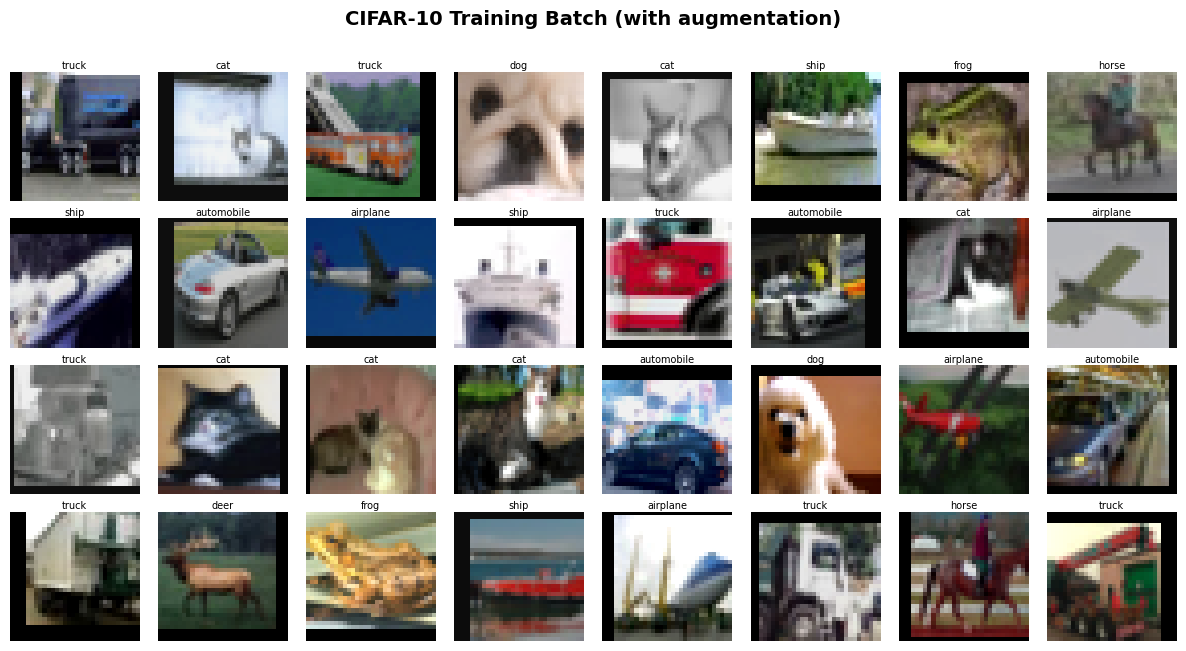

In [11]:
def denormalize(tensor, mean, std):
    """
    Reverse Normalize transform for visualization.
    Works on a single image tensor (C, H, W) or a batch (B, C, H, W).
    """
    mean = torch.tensor(mean).view(-1, 1, 1)  # (C, 1, 1) for broadcasting
    std  = torch.tensor(std).view(-1, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


def show_batch(loader, dataset_classes, mean, std, n_rows=4, n_cols=8, title='Batch'):
    """
    Visualize one batch from a DataLoader.
    Shows images in a grid with class labels as titles.
    """
    images, labels = next(iter(loader))
    n_show = min(n_rows * n_cols, len(images))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.6))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)

    for i, ax in enumerate(axes.flat):
        if i >= n_show:
            ax.axis('off')
            continue
        # Tensor (C,H,W) → numpy (H,W,C), denormalized
        img = denormalize(images[i], mean, std)
        img_np = img.permute(1, 2, 0).numpy()   # (H,W,C)
        ax.imshow(img_np)
        ax.set_title(dataset_classes[labels[i]], fontsize=7, pad=2)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    return images, labels


print('CIFAR-10 Training Batch (with augmentation):')
imgs, lbls = show_batch(
    train_loader, cifar10_train_aug.classes,
    CIFAR10_MEAN, CIFAR10_STD,
    n_rows=4, n_cols=8,
    title='CIFAR-10 Training Batch (with augmentation)'
)

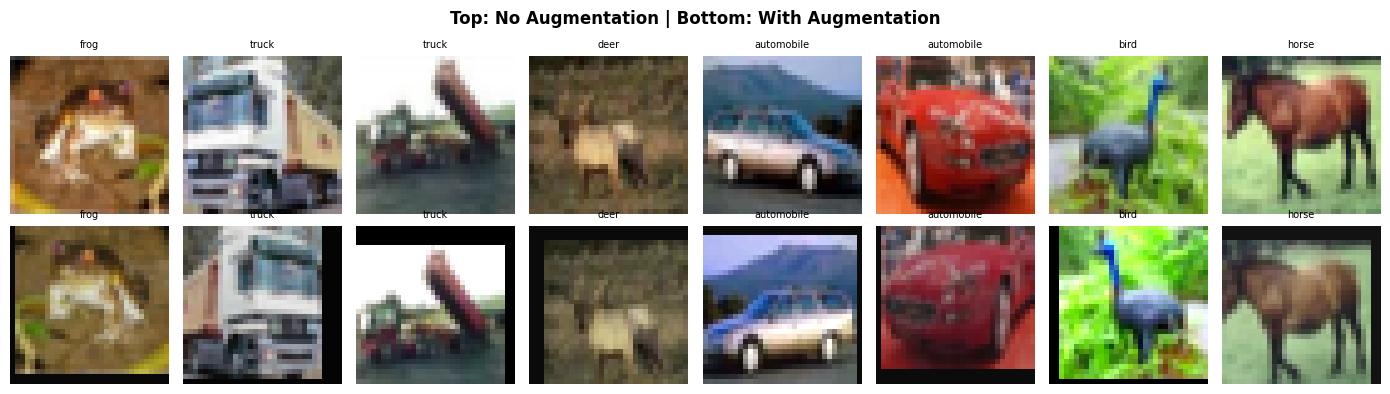

In [12]:
# ─── Compare augmented vs non-augmented ──────────────────────────────────────
no_aug_loader = DataLoader(
    datasets.CIFAR10(root='./data', train=True, transform=val_transform, download=False),
    batch_size=16, shuffle=False
)
aug_loader_small = DataLoader(
    cifar10_train_aug, batch_size=16, shuffle=False
)

# Use the same underlying indices by NOT shuffling, so we compare the same images
imgs_noaug, lbls1 = next(iter(no_aug_loader))
imgs_aug,   lbls2 = next(iter(aug_loader_small))

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('Top: No Augmentation | Bottom: With Augmentation', fontsize=12, fontweight='bold')

for col in range(8):
    for row, (imgs, lbl) in enumerate([(imgs_noaug, lbls1), (imgs_aug, lbls2)]):
        img = denormalize(imgs[col], CIFAR10_MEAN, CIFAR10_STD).permute(1,2,0).numpy()
        axes[row, col].imshow(img)
        axes[row, col].set_title(cifar10_train_aug.classes[lbl[col]], fontsize=7)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

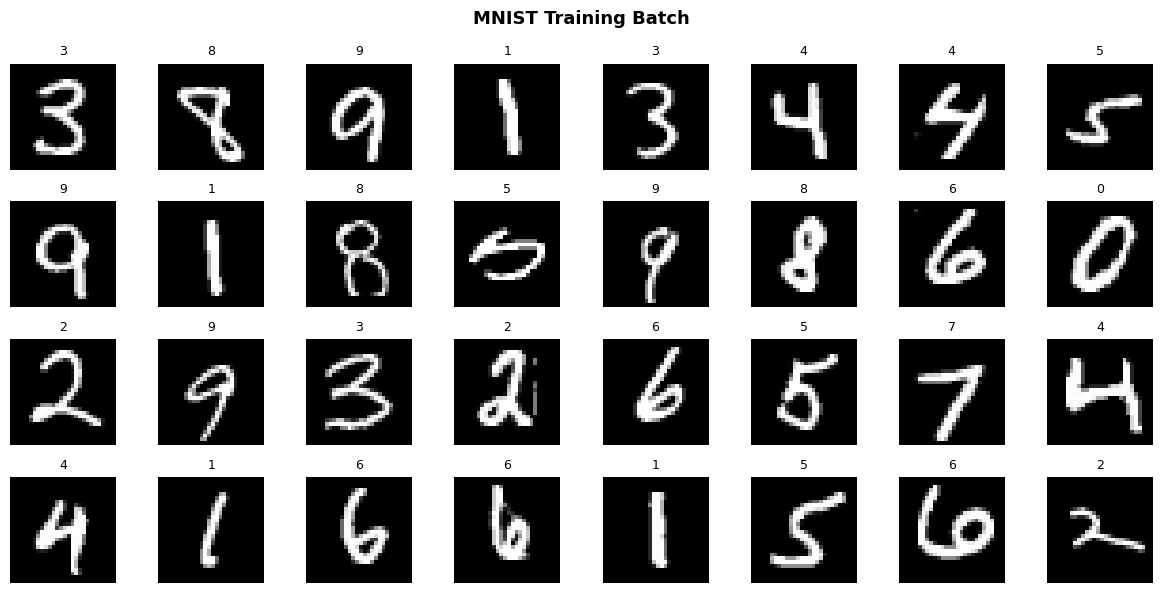

In [13]:
# ─── MNIST batch visualization ────────────────────────────────────────────────
MNIST_MEAN = (0.1307,)
MNIST_STD  = (0.3081,)

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD)
])

mnist_train_norm = datasets.MNIST(root='./data', train=True, transform=mnist_transform, download=False)
mnist_loader = DataLoader(mnist_train_norm, batch_size=32, shuffle=True)

images_m, labels_m = next(iter(mnist_loader))

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
fig.suptitle('MNIST Training Batch', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = denormalize(images_m[i], MNIST_MEAN, MNIST_STD)
    ax.imshow(img.squeeze().numpy(), cmap='gray')
    ax.set_title(str(labels_m[i].item()), fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 4.1 Pixel Statistics Sanity Check

It's also useful to plot the distribution of pixel values to verify normalization is working:

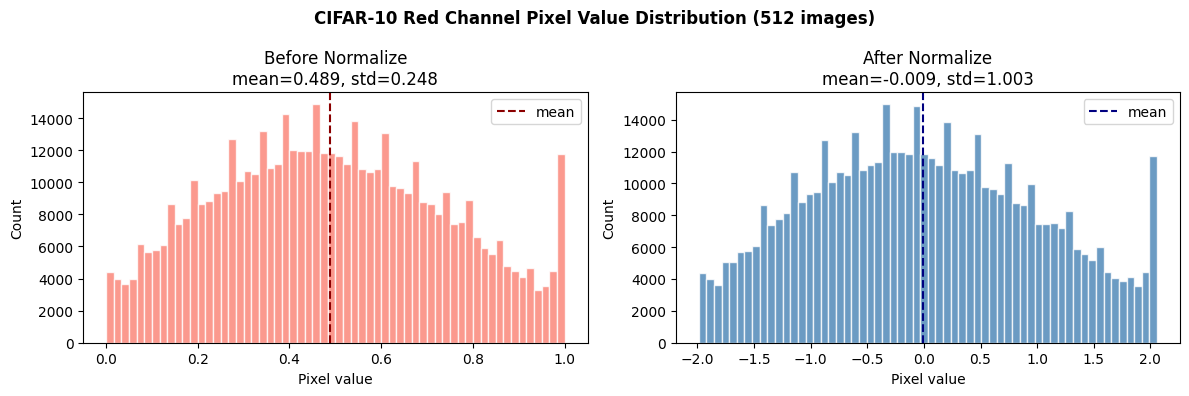

In [14]:
# Compare pixel distribution before and after normalization
raw_loader = DataLoader(
    datasets.CIFAR10(root='./data', train=True,
                     transform=transforms.ToTensor(), download=False),
    batch_size=512, shuffle=False
)
norm_loader = DataLoader(
    datasets.CIFAR10(root='./data', train=True,
                     transform=transforms.Compose([
                         transforms.ToTensor(),
                         transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
                     ]), download=False),
    batch_size=512, shuffle=False
)

raw_pixels  = next(iter(raw_loader))[0][:, 0].flatten().numpy()   # Red channel
norm_pixels = next(iter(norm_loader))[0][:, 0].flatten().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CIFAR-10 Red Channel Pixel Value Distribution (512 images)', fontsize=12, fontweight='bold')

ax1.hist(raw_pixels,  bins=60, color='salmon',   edgecolor='white', alpha=0.8)
ax1.set_title(f'Before Normalize\nmean={raw_pixels.mean():.3f}, std={raw_pixels.std():.3f}')
ax1.set_xlabel('Pixel value'); ax1.set_ylabel('Count')
ax1.axvline(raw_pixels.mean(), color='darkred', linestyle='--', label='mean')
ax1.legend()

ax2.hist(norm_pixels, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax2.set_title(f'After Normalize\nmean={norm_pixels.mean():.3f}, std={norm_pixels.std():.3f}')
ax2.set_xlabel('Pixel value'); ax2.set_ylabel('Count')
ax2.axvline(norm_pixels.mean(), color='navy', linestyle='--', label='mean')
ax2.legend()

plt.tight_layout()
plt.show()

---
## 5. Exercise: Build a Custom `Dataset` Class

### When do you need a custom Dataset?

The built-in torchvision datasets are convenient, but real projects rarely use them. You'll need a custom `Dataset` when:
- Images are stored in a custom directory structure
- Labels come from a CSV, JSON, or database — not the folder name
- Each sample requires special loading logic (e.g., paired images, multi-label)
- You need to apply sample-specific transforms based on metadata

### The `Dataset` Interface

```python
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self, ...):
        # One-time setup: read file lists, load CSV, etc.
        ...

    def __len__(self):
        # Returns total number of samples
        return len(self.file_list)

    def __getitem__(self, idx):
        # Load and return ONE sample given its index
        # This is called by DataLoader workers in parallel
        ...
        return image_tensor, label
```

### 5.1 Create a Synthetic Local Image Folder (Setup)

We'll generate a synthetic dataset to work with:

In [15]:
import random
import json

# ─── Generate a synthetic dataset ─────────────────────────────────────────────
DATA_ROOT   = Path('./my_image_dataset')
CLASS_NAMES = ['cats', 'dogs', 'birds']
N_IMAGES    = 30   # 30 images per class → 90 total

def make_synthetic_image(class_idx, size=(64, 64)):
    """Create a distinct colored image per class (placeholder for real images)."""
    base_colors = [(200, 80, 80), (80, 120, 200), (80, 180, 100)]
    r, g, b = base_colors[class_idx]
    # Add noise so images aren't identical
    arr = np.full((*size, 3), [r, g, b], dtype=np.uint8)
    arr += np.random.randint(-30, 30, arr.shape, dtype=np.int16).clip(0, 255).astype(np.uint8)
    return Image.fromarray(arr.clip(0, 255).astype(np.uint8))

# Build folder structure:
#   my_image_dataset/
#     cats/   img_0000.jpg ... img_0029.jpg
#     dogs/   img_0000.jpg ...
#     birds/  img_0000.jpg ...
#     labels.json

metadata = {}   # { 'relative/path.jpg': label_index }
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_dir = DATA_ROOT / cls_name
    cls_dir.mkdir(parents=True, exist_ok=True)
    for i in range(N_IMAGES):
        # Vary image sizes to test our Dataset's handling of variable sizes
        h = random.choice([48, 56, 64, 72])
        w = random.choice([48, 56, 64, 72])
        img = make_synthetic_image(cls_idx, size=(h, w))
        fname = f'img_{i:04d}.jpg'
        fpath = cls_dir / fname
        img.save(fpath, quality=90)
        metadata[f'{cls_name}/{fname}'] = cls_idx

# Save metadata as JSON (simulates a label CSV/JSON in real projects)
with open(DATA_ROOT / 'labels.json', 'w') as f:
    json.dump({'classes': CLASS_NAMES, 'labels': metadata}, f, indent=2)

# Summarize
total_images = sum(1 for _ in DATA_ROOT.rglob('*.jpg'))
print(f'Created synthetic dataset at: {DATA_ROOT.resolve()}')
print(f'Directory structure:')
for cls in CLASS_NAMES:
    count = len(list((DATA_ROOT / cls).glob('*.jpg')))
    print(f'  {DATA_ROOT}/{cls}/  → {count} images')
print(f'Total images: {total_images}')
print(f'labels.json written with {len(metadata)} entries')

Created synthetic dataset at: /content/my_image_dataset
Directory structure:
  my_image_dataset/cats/  → 30 images
  my_image_dataset/dogs/  → 30 images
  my_image_dataset/birds/  → 30 images
Total images: 90
labels.json written with 90 entries


### 5.2 Implement `ImageFolderDataset`

We'll build a custom Dataset that reads from the folder structure above. This pattern covers the majority of real-world use cases:

In [16]:
class ImageFolderDataset(Dataset):
    """
    Custom Dataset for loading images from a directory.

    Expects either:
      (a) A root dir where each sub-folder is a class name, OR
      (b) A root dir + labels.json file with metadata

    Args:
        root      : Path to the dataset root directory
        transform : Optional torchvision transform pipeline
        split     : 'train', 'val', or None (use all data)
        val_frac  : Fraction of data to use as validation (default: 0.2)
        seed      : Random seed for train/val split
    """

    def __init__(self,
                 root: str,
                 transform=None,
                 split: str = None,
                 val_frac: float = 0.2,
                 seed: int = 42):

        self.root      = Path(root)
        self.transform = transform

        # ── Load class names and label map ───────────────────────────────────
        labels_file = self.root / 'labels.json'
        if labels_file.exists():
            # Option B: load from JSON metadata
            with open(labels_file) as f:
                meta = json.load(f)
            self.classes    = meta['classes']
            self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
            all_samples = [(self.root / k, v) for k, v in meta['labels'].items()]
        else:
            # Option A: infer classes from sub-folder names
            self.classes = sorted([d.name for d in self.root.iterdir() if d.is_dir()])
            self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
            all_samples = []
            for cls_name, cls_idx in self.class_to_idx.items():
                cls_dir = self.root / cls_name
                for img_path in sorted(cls_dir.glob('*.jpg')) + sorted(cls_dir.glob('*.png')):
                    all_samples.append((img_path, cls_idx))

        # ── Train / Val split ────────────────────────────────────────────────
        rng = random.Random(seed)
        indices = list(range(len(all_samples)))
        rng.shuffle(indices)

        n_val = int(len(indices) * val_frac)
        val_idx   = set(indices[:n_val])
        train_idx = set(indices[n_val:])

        if split == 'train':
            self.samples = [all_samples[i] for i in range(len(all_samples)) if i in train_idx]
        elif split == 'val':
            self.samples = [all_samples[i] for i in range(len(all_samples)) if i in val_idx]
        else:
            self.samples = all_samples

    # ── Required Dataset methods ─────────────────────────────────────────────

    def __len__(self):
        """Total number of samples in this split."""
        return len(self.samples)

    def __getitem__(self, idx):
        """
        Load and return the sample at position `idx`.

        Returns:
            image  : Tensor (C, H, W) if transform includes ToTensor, else PIL Image
            label  : int class index
        """
        img_path, label = self.samples[idx]

        # Load image from disk as RGB PIL Image
        image = Image.open(img_path).convert('RGB')   # .convert ensures 3 channels

        # Apply the transform pipeline (resize, augment, ToTensor, normalize, ...)
        if self.transform is not None:
            image = self.transform(image)

        return image, label

    # ── Convenience methods ──────────────────────────────────────────────────

    def __repr__(self):
        return (
            f'{self.__class__.__name__}(\n'
            f'  root    = {self.root}\n'
            f'  classes = {self.classes}\n'
            f'  samples = {len(self.samples)}\n'
            f')'
        )

    def class_counts(self):
        """Return a dict {class_name: count} for the current split."""
        counts = {c: 0 for c in self.classes}
        for _, label in self.samples:
            counts[self.classes[label]] += 1
        return counts


print('ImageFolderDataset class defined.')

ImageFolderDataset class defined.


### 5.3 Instantiate and Verify the Custom Dataset

In [17]:
# ─── Define transforms for our custom dataset ─────────────────────────────────
custom_train_tfm = transforms.Compose([
    transforms.Resize((64, 64)),          # Standardize variable-size images
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])  # Simple [-1,1] normalization
])

custom_val_tfm = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# ─── Instantiate train / val splits ──────────────────────────────────────────
train_ds = ImageFolderDataset(
    root      = './my_image_dataset',
    transform = custom_train_tfm,
    split     = 'train',
    val_frac  = 0.2,
    seed      = 42
)

val_ds = ImageFolderDataset(
    root      = './my_image_dataset',
    transform = custom_val_tfm,
    split     = 'val',
    val_frac  = 0.2,
    seed      = 42
)

print(train_ds)
print()
print(val_ds)
print()
print(f'Train class distribution: {train_ds.class_counts()}')
print(f'Val   class distribution: {val_ds.class_counts()}')

ImageFolderDataset(
  root    = my_image_dataset
  classes = ['cats', 'dogs', 'birds']
  samples = 72
)

ImageFolderDataset(
  root    = my_image_dataset
  classes = ['cats', 'dogs', 'birds']
  samples = 18
)

Train class distribution: {'cats': 25, 'dogs': 22, 'birds': 25}
Val   class distribution: {'cats': 5, 'dogs': 8, 'birds': 5}


In [18]:
# ─── Verify __getitem__ works correctly ───────────────────────────────────────
img0, lbl0 = train_ds[0]
print('Sample 0 from custom dataset:')
print(f'  type  : {type(img0)}')
print(f'  shape : {img0.shape}')
print(f'  dtype : {img0.dtype}')
print(f'  range : [{img0.min():.3f}, {img0.max():.3f}]')
print(f'  label : {lbl0} → "{train_ds.classes[lbl0]}"')

# Verify the split doesn't overlap (no sample appears in both train and val)
train_paths = {str(p) for p, _ in train_ds.samples}
val_paths   = {str(p) for p, _ in val_ds.samples}
overlap     = train_paths & val_paths
print(f'\nTrain/Val overlap: {len(overlap)} samples (should be 0)')

Sample 0 from custom dataset:
  type  : <class 'torch.Tensor'>
  shape : torch.Size([3, 64, 64])
  dtype : torch.float32
  range : [-0.522, 1.000]
  label : 0 → "cats"

Train/Val overlap: 0 samples (should be 0)


### 5.4 Wrap in DataLoaders and Visualize

Custom train batches: 6
Custom val batches  : 2


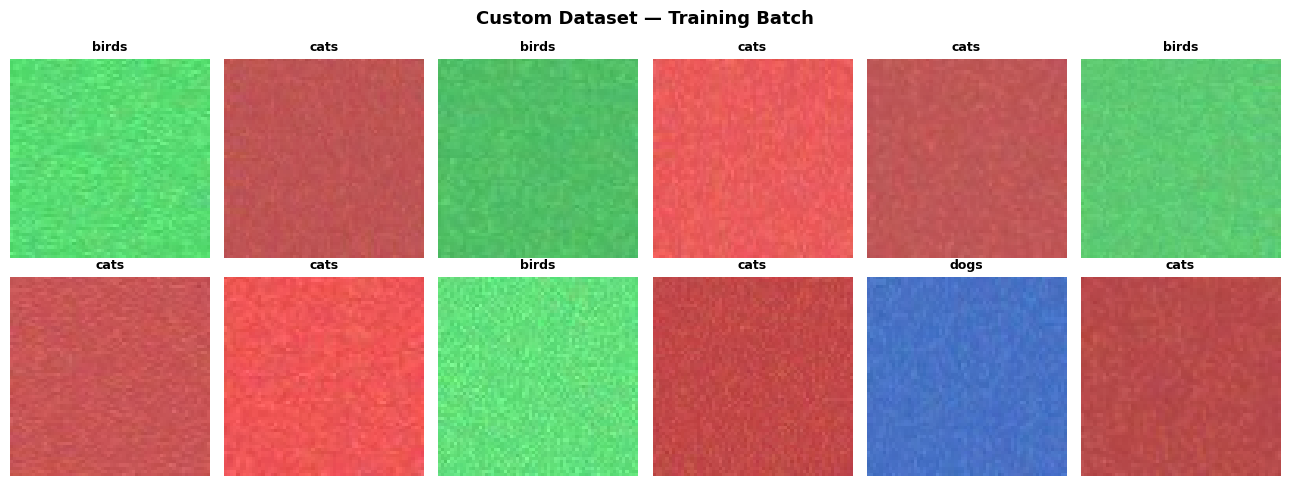

In [19]:
custom_train_loader = DataLoader(train_ds, batch_size=12, shuffle=True,  num_workers=0)
custom_val_loader   = DataLoader(val_ds,   batch_size=12, shuffle=False, num_workers=0)

print(f'Custom train batches: {len(custom_train_loader)}')
print(f'Custom val batches  : {len(custom_val_loader)}')

# Visualize a training batch
images_c, labels_c = next(iter(custom_train_loader))

fig, axes = plt.subplots(2, 6, figsize=(13, 5))
fig.suptitle('Custom Dataset — Training Batch', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i >= len(images_c):
        ax.axis('off')
        continue
    # De-normalize from [-1,1] back to [0,1]
    img = images_c[i] * 0.5 + 0.5
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
    ax.set_title(train_ds.classes[labels_c[i]], fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

### 5.5 Extension: CSV-Based Label Loading

In many real projects, labels are stored in a CSV file (think: Kaggle competitions, medical imaging datasets). Here's how to adapt `__init__` for that pattern:

In [20]:
import csv

class CSVLabeledDataset(Dataset):
    """
    Dataset where labels are stored in a CSV file.

    CSV format (no header):
        relative/path/to/image.jpg,label_index

    Or with header:
        filepath,label
        cats/img_0000.jpg,0
        ...
    """

    def __init__(self, root, csv_file, classes, transform=None, has_header=True):
        self.root      = Path(root)
        self.classes   = classes
        self.transform = transform
        self.samples   = []

        with open(csv_file, newline='') as f:
            reader = csv.reader(f)
            if has_header:
                next(reader)                          # skip header row
            for row in reader:
                rel_path, label = row[0], int(row[1])
                full_path = self.root / rel_path
                self.samples.append((full_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


# ─── Generate a CSV file for our synthetic dataset ────────────────────────────
csv_path = DATA_ROOT / 'labels.csv'
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['filepath', 'label'])
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        for img_path in sorted((DATA_ROOT / cls_name).glob('*.jpg')):
            rel = f'{cls_name}/{img_path.name}'
            writer.writerow([rel, cls_idx])

print(f'CSV written to {csv_path}')

# Test it
csv_ds = CSVLabeledDataset(
    root      = './my_image_dataset',
    csv_file  = str(csv_path),
    classes   = CLASS_NAMES,
    transform = custom_val_tfm,
    has_header= True
)

print(f'CSVLabeledDataset loaded {len(csv_ds)} samples')
img, lbl = csv_ds[5]
print(f'Sample 5: shape={img.shape}, label={lbl} ({CLASS_NAMES[lbl]})')

CSV written to my_image_dataset/labels.csv
CSVLabeledDataset loaded 90 samples
Sample 5: shape=torch.Size([3, 64, 64]), label=0 (cats)


---
## Summary & Key Takeaways

| Concept | Key Points |
|---|---|
| **`torchvision.datasets`** | Built-in loaders for MNIST, CIFAR-10, ImageNet, etc. All inherit from `Dataset` and implement `__len__` + `__getitem__` |
| **`transforms.Compose`** | Sequential pipeline of image operations. Apply augmentation only to training data; use deterministic transforms for val/test |
| **Normalization** | Always normalize with `transforms.Normalize(mean, std)`. Compute stats from training set only. |
| **`DataLoader`** | Wraps a `Dataset` to produce batches. Use `shuffle=True` for training, `False` for val/test. Tune `num_workers` for throughput. |
| **`pin_memory=True`** | Pre-pins CPU memory for faster transfers to GPU. Enable when using CUDA. |
| **Custom `Dataset`** | Subclass `Dataset`, implement `__len__` and `__getitem__`. Load one sample per call — `DataLoader` handles batching. |

### Common Pitfalls

1. **Applying augmentation to val/test** — creates non-reproducible evaluation. Keep val/test transforms deterministic.
2. **Forgetting `ToTensor()`** — PIL Images can't be batched into tensors. Always convert.
3. **Wrong normalization channel order** — PyTorch tensors are `(C, H, W)`, but `Normalize(mean, std)` expects mean/std in the same channel order as your data (usually RGB).
4. **`num_workers > 0` on macOS notebooks** — can cause multiprocessing errors. Use `0` or wrap in `if __name__ == '__main__'`.
5. **Not using `.convert('RGB')` in custom Dataset** — some images have 4 channels (RGBA) or are grayscale. Always convert for consistency.

---
### Next Steps → Module 3: Building Your First CNN

Now that data flows correctly into batches, we'll plug `DataLoader` output directly into a convolutional neural network and train it end-to-end.

In [21]:
# ─── Quick recap: end-to-end data pipeline in ~10 lines ──────────────────────

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

train_dataset = datasets.CIFAR10('./data', train=True, transform=train_transform, download=False)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

# This is all you need to feed a model:
for images, labels in train_loader:
    images = images.to(DEVICE)   # → (64, 3, 32, 32) on GPU if available
    labels = labels.to(DEVICE)   # → (64,)
    # model(images), loss.backward(), optimizer.step() ...
    break  # just show one iteration

print(f'Ready to train! Batch shape: images={images.shape}, labels={labels.shape}')
print(f'Device: {images.device}')

Ready to train! Batch shape: images=torch.Size([64, 3, 32, 32]), labels=torch.Size([64])
Device: cpu
